# 05 — Event-study and DiD-style analyses

In [13]:
from dataclasses import dataclass
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
try:
    from IPython.display import display
except ImportError:
    def display(value):
        if hasattr(value, "to_string"):
            print(value.to_string(index=False))
        else:
            print(value)

YEARS = list(range(2020, 2026))
BASE_YEAR = 2022
PRE_YEARS = (2020, 2021, 2022)
POST_YEARS = (2023, 2024, 2025)
ALPHA = 0.05
DECISION_COLUMN = "finetuned_decision"
AUTHOR_COLUMN = "first_author_id"

search_roots = [Path.cwd(), *Path.cwd().parents]
REPO_ROOT = next(
    (
        root
        for root in search_roots
        if (root / "data" / "processed" / "id_papers.csv").exists()
    ),
    None,
)
if REPO_ROOT is None:
    raise FileNotFoundError(
        "Could not locate data/processed/id_papers.csv from the current directory."
    )
INPUT_CSV = REPO_ROOT / "data" / "processed" / "id_papers.csv"
SOURCE_DIR = REPO_ROOT / "data" / "source_data" / "05_event_study_and_did"
SOURCE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Repository root: {REPO_ROOT}")
print(f"Input data: {INPUT_CSV}")
print(f"Source-data directory: {SOURCE_DIR}")

Repository root: /home/user/GSK/lily/science_of_science/NewDataset/llm_impact_on_ai_pub
Input data: /home/user/GSK/lily/science_of_science/NewDataset/llm_impact_on_ai_pub/data/processed/id_papers.csv
Source-data directory: /home/user/GSK/lily/science_of_science/NewDataset/llm_impact_on_ai_pub/data/source_data/05_event_study_and_did


## Analysis dimensions and model specifications

In [14]:
@dataclass(frozen=True)
class Dimension:
    key: str
    label: str
    column: str
    categories: tuple[str, ...]
    reference: str

    @property
    def contrasts(self) -> tuple[str, ...]:
        return tuple(x for x in self.categories if x != self.reference)


@dataclass(frozen=True)
class Specification:
    key: str
    label: str
    conference_fixed_effects: bool
    other_dimension_controls: bool


DIMENSIONS = (
    Dimension(
        key="first_author_academic_age",
        label="First-author academic age",
        column="age_group",
        categories=("0–3 years", "4–10 years", "10+ years"),
        reference="4–10 years",
    ),
    Dimension(
        key="first_author_language_environment",
        label="First-author language environment",
        column="first_language_group",
        categories=(
            "English-language environment",
            "Non-English-language environment",
        ),
        reference="English-language environment",
    ),
    Dimension(
        key="conference_track",
        label="Conference track type",
        column="track_group",
        categories=("Main track", "Non-main track"),
        reference="Main track",
    ),
)

SPECIFICATIONS = (
    Specification(
        key="year_fe_only",
        label="Year fixed effects only",
        conference_fixed_effects=False,
        other_dimension_controls=False,
    ),
    Specification(
        key="year_and_conference_fe",
        label="Year and conference fixed effects",
        conference_fixed_effects=True,
        other_dimension_controls=False,
    ),
    Specification(
        key="fully_adjusted",
        label="Year and conference fixed effects + other focal dimensions",
        conference_fixed_effects=True,
        other_dimension_controls=True,
    ),
)

TERM_LABELS = {
    ("first_author_academic_age", "0–3 years"):
        "Early-career vs Mid-career × Post",
    ("first_author_academic_age", "10+ years"):
        "Senior vs Mid-career × Post",
    (
        "first_author_language_environment",
        "Non-English-language environment",
    ): "Non-English vs English × Post",
    ("conference_track", "Non-main track"):
        "Non-main track vs Main track × Post",
}

print("Dimensions:", ", ".join(d.key for d in DIMENSIONS))
print("Specifications:", ", ".join(s.key for s in SPECIFICATIONS))

Dimensions: first_author_academic_age, first_author_language_environment, conference_track
Specifications: year_fe_only, year_and_conference_fe, fully_adjusted


## Load, recode, and inspect the paper-level data

In [15]:
required_columns = {
    "id",
    "Conference",
    "Year",
    DECISION_COLUMN,
    AUTHOR_COLUMN,
    "first_author_academic_age",
    "first_author_language_environment",
    "track_type",
}
papers = pd.read_csv(INPUT_CSV, encoding="utf-8-sig", low_memory=False)
missing_columns = sorted(required_columns - set(papers.columns))
if missing_columns:
    raise KeyError(f"Missing required columns: {missing_columns}")

papers["Year"] = pd.to_numeric(papers["Year"], errors="coerce")
papers[DECISION_COLUMN] = pd.to_numeric(
    papers[DECISION_COLUMN], errors="coerce"
)
papers[AUTHOR_COLUMN] = papers[AUTHOR_COLUMN].astype("string").str.strip()
papers.loc[
    papers[AUTHOR_COLUMN].isin(["", "nan", "None", "<NA>"]),
    AUTHOR_COLUMN,
] = pd.NA
papers["Conference"] = papers["Conference"].astype("string").str.strip()

papers = papers.loc[
    papers["Year"].isin(YEARS)
    & papers[DECISION_COLUMN].isin([0, 1])
    & papers["Conference"].notna()
].copy()
papers["Year"] = papers["Year"].astype(int)
papers["outcome"] = papers[DECISION_COLUMN].eq(0).astype(float)

academic_age = pd.to_numeric(
    papers["first_author_academic_age"], errors="coerce"
).where(lambda values: values.between(0, 60))
papers["age_group"] = pd.cut(
    academic_age,
    bins=[-0.001, 3, 10, np.inf],
    labels=["0–3 years", "4–10 years", "10+ years"],
    include_lowest=True,
    ordered=True,
)

papers["first_language_group"] = (
    papers["first_author_language_environment"]
    .astype("string")
    .str.strip()
    .map(
        {
            "English_environment": "English-language environment",
            "Non_English_environment": "Non-English-language environment",
        }
    )
)
papers["track_group"] = (
    papers["track_type"]
    .astype("string")
    .str.strip()
    .map(
        {
            "main_track": "Main track",
            "non-main_track": "Non-main track",
            "non_main_track": "Non-main track",
        }
    )
)

for dimension in DIMENSIONS:
    papers[dimension.column] = pd.Categorical(
        papers[dimension.column],
        categories=dimension.categories,
        ordered=True,
    )

completeness = []
for dimension in DIMENSIONS:
    completeness.append(
        {
            "dimension": dimension.key,
            "n_total_analysis_rows": len(papers),
            "n_valid_for_dimension": int(
                papers[dimension.column].notna().sum()
            ),
            "n_missing_or_invalid_for_dimension": int(
                papers[dimension.column].isna().sum()
            ),
        }
    )
completeness = pd.DataFrame(completeness)
common_sample = papers.dropna(
    subset=[
        "outcome",
        "Year",
        "Conference",
        AUTHOR_COLUMN,
        *(dimension.column for dimension in DIMENSIONS),
    ]
)
completeness["n_common_sample_with_author_id"] = len(common_sample)
completeness_path = SOURCE_DIR / "data_completeness.csv"
completeness.to_csv(completeness_path, index=False, encoding="utf-8-sig")

print(f"Eligible paper records before dimension-specific filtering: {len(papers):,}")
print(f"Complete-case sample with first-author IDs: {len(common_sample):,}")
display(completeness)

Eligible paper records before dimension-specific filtering: 91,856
Complete-case sample with first-author IDs: 52,697


,dimension,n_total_analysis_rows,n_valid_for_dimension,n_missing_or_invalid_for_dimension,n_common_sample_with_author_id
0,first_author_academic_age,91856,83443,8413,52697
1,first_author_language_environment,91856,53955,37901,52697
2,conference_track,91856,91856,0,52697


## Regression and inference helpers

In [16]:
def prepare_model_sample(
    frame: pd.DataFrame,
    dimension: Dimension,
    specification: Specification,
) -> pd.DataFrame:
    required_groups = [dimension.column]
    sample_strategy = "maximum focal-dimension sample"
    if specification.other_dimension_controls:
        required_groups = [item.column for item in DIMENSIONS]
        sample_strategy = "complete cases across all focal dimensions"

    data = frame.dropna(
        subset=[
            "outcome",
            "Year",
            "Conference",
            AUTHOR_COLUMN,
            *required_groups,
        ]
    ).copy()
    observed = set(data[dimension.column].astype("string").dropna())
    missing = set(dimension.categories) - observed
    if missing:
        raise ValueError(
            f"{dimension.key} is missing categories: {sorted(missing)}"
        )
    data.attrs["sample_strategy"] = sample_strategy
    return data


def fit_clustered_ols(data: pd.DataFrame, formula: str):
    groups = pd.Categorical(data[AUTHOR_COLUMN]).codes
    if np.any(groups < 0):
        raise ValueError("Missing first-author IDs remain in model data.")
    return smf.ols(formula, data=data).fit(
        cov_type="cluster",
        cov_kwds={
            "groups": groups,
            "use_correction": True,
            "df_correction": True,
        },
        use_t=True,
    )


def coefficient_record(model, variable: str) -> dict:
    confidence = model.conf_int(alpha=ALPHA).loc[variable]
    return {
        "estimate": float(model.params[variable]),
        "std_error": float(model.bse[variable]),
        "ci_lower": float(confidence.iloc[0]),
        "ci_upper": float(confidence.iloc[1]),
        "t_value": float(model.tvalues[variable]),
        "p_value": float(model.pvalues[variable]),
    }


def joint_test(model, variables: list[str]) -> dict:
    restriction = ", ".join(f"{variable} = 0" for variable in variables)
    test = model.f_test(restriction)
    return {
        "f_statistic": float(np.asarray(test.fvalue).squeeze()),
        "p_value": float(np.asarray(test.pvalue).squeeze()),
        "df_numerator": int(test.df_num),
        "df_denominator": int(test.df_denom),
    }


def build_common_formula_terms(
    dimension: Dimension,
    specification: Specification,
) -> tuple[list[str], tuple[str, ...]]:
    focal = (
        f"C({dimension.column}, "
        f"Treatment(reference={dimension.reference!r}))"
    )
    terms = ["C(Year)", focal]
    if specification.conference_fixed_effects:
        terms.append("C(Conference)")
    controls = ()
    if specification.other_dimension_controls:
        controls = tuple(
            other.column for other in DIMENSIONS if other.key != dimension.key
        )
        terms.extend(f"C({column})" for column in controls)
    return terms, controls


print("Regression helpers ready.")
print("Covariance estimator: first-author clustered with finite-sample corrections.")

Regression helpers ready.
Covariance estimator: first-author clustered with finite-sample corrections.


## Event-study models

In [17]:
event_rows = []
pretrend_rows = []
diagnostic_rows = []
sample_check_rows = []

for specification in SPECIFICATIONS:
    for dimension in DIMENSIONS:
        data = prepare_model_sample(papers, dimension, specification)
        sample_check_rows.append(
            {
                "analysis": "event_study",
                "specification": specification.key,
                "dimension": dimension.key,
                "n_papers": len(data),
                "n_first_authors": data[AUTHOR_COLUMN].nunique(),
                "sample_strategy": data.attrs["sample_strategy"],
            }
        )

        lookup = {}
        for contrast_index, contrast in enumerate(dimension.contrasts):
            for year in YEARS:
                if year == BASE_YEAR:
                    continue
                variable = f"event_g{contrast_index}_y{year}"
                data[variable] = (
                    data[dimension.column].eq(contrast)
                    & data["Year"].eq(year)
                ).astype(np.int8)
                lookup[(contrast, year)] = variable

        terms, controls = build_common_formula_terms(
            dimension, specification
        )
        terms.extend(lookup.values())
        formula = "outcome ~ " + " + ".join(terms)
        model = fit_clustered_ols(data, formula)

        for contrast in dimension.contrasts:
            for year in YEARS:
                if year == BASE_YEAR:
                    coefficient = {
                        "estimate": 0.0,
                        "std_error": 0.0,
                        "ci_lower": 0.0,
                        "ci_upper": 0.0,
                        "t_value": np.nan,
                        "p_value": np.nan,
                    }
                    omitted = True
                else:
                    coefficient = coefficient_record(
                        model, lookup[(contrast, year)]
                    )
                    omitted = False
                event_rows.append(
                    {
                        "specification": specification.key,
                        "specification_label": specification.label,
                        "dimension": dimension.key,
                        "dimension_label": dimension.label,
                        "contrast_group": contrast,
                        "reference_group": dimension.reference,
                        "Year": year,
                        "event_time": year - BASE_YEAR,
                        "base_year": BASE_YEAR,
                        "omitted_baseline": omitted,
                        **coefficient,
                        "estimate_percentage_points": 100 * coefficient["estimate"],
                        "std_error_percentage_points": 100 * coefficient["std_error"],
                        "ci_lower_percentage_points": 100 * coefficient["ci_lower"],
                        "ci_upper_percentage_points": 100 * coefficient["ci_upper"],
                        "n_model": int(model.nobs),
                        "n_first_authors": data[AUTHOR_COLUMN].nunique(),
                    }
                )

            variables = [
                lookup[(contrast, year)]
                for year in YEARS
                if year < BASE_YEAR
            ]
            test = joint_test(model, variables)
            pretrend_rows.append(
                {
                    "specification": specification.key,
                    "dimension": dimension.key,
                    "test_scope": "contrast",
                    "contrast_group": contrast,
                    "reference_group": dimension.reference,
                    "tested_pre_years": "2020,2021",
                    **test,
                    "parallel_trend_not_rejected_at_0_05": (
                        test["p_value"] >= 0.05
                    ),
                    "n_model": int(model.nobs),
                }
            )

        all_pre_variables = [
            lookup[(contrast, year)]
            for contrast in dimension.contrasts
            for year in YEARS
            if year < BASE_YEAR
        ]
        global_test = joint_test(model, all_pre_variables)
        pretrend_rows.append(
            {
                "specification": specification.key,
                "dimension": dimension.key,
                "test_scope": "dimension_global",
                "contrast_group": "<all contrasts>",
                "reference_group": dimension.reference,
                "tested_pre_years": "2020,2021",
                **global_test,
                "parallel_trend_not_rejected_at_0_05": (
                    global_test["p_value"] >= 0.05
                ),
                "n_model": int(model.nobs),
            }
        )

        diagnostic_rows.append(
            {
                "analysis": "event_study",
                "specification": specification.key,
                "dimension": dimension.key,
                "formula": formula,
                "controls": ",".join(controls),
                "n_papers": int(model.nobs),
                "n_first_authors": data[AUTHOR_COLUMN].nunique(),
                "n_conferences": data["Conference"].nunique(),
                "n_parameters": model.model.exog.shape[1],
                "design_matrix_rank": np.linalg.matrix_rank(model.model.exog),
                "base_year": BASE_YEAR,
                "covariance": "first-author clustered",
            }
        )

event_results = pd.DataFrame(event_rows)
pretrend_results = pd.DataFrame(pretrend_rows)
sample_checks = pd.DataFrame(sample_check_rows)
diagnostics = pd.DataFrame(diagnostic_rows)

print("Fully adjusted global pre-trend tests:")
display(
    pretrend_results.loc[
        pretrend_results["specification"].eq("fully_adjusted")
        & pretrend_results["test_scope"].eq("dimension_global"),
        [
            "dimension",
            "f_statistic",
            "p_value",
            "df_numerator",
            "df_denominator",
            "n_model",
        ],
    ]
)

Fully adjusted global pre-trend tests:


,dimension,f_statistic,p_value,df_numerator,df_denominator,n_model
16,first_author_academic_age,0.560230,0.691547,4,38405,52697
18,first_author_language_environment,0.399384,0.670736,2,38405,52697
20,conference_track,1.136611,0.320915,2,38405,52697


## DiD-style models

In [18]:
did_rows = []
did_joint_rows = []

did_papers = papers.copy()
did_papers["Post"] = did_papers["Year"].isin(POST_YEARS).astype(np.int8)

for specification in SPECIFICATIONS:
    for dimension in DIMENSIONS:
        data = prepare_model_sample(
            did_papers, dimension, specification
        )
        lookup = {}
        for contrast_index, contrast in enumerate(dimension.contrasts):
            variable = f"did_group_{contrast_index}_post"
            data[variable] = (
                data[dimension.column].eq(contrast)
                & data["Post"].eq(1)
            ).astype(np.int8)
            lookup[contrast] = variable

        terms, controls = build_common_formula_terms(
            dimension, specification
        )
        terms.extend(lookup.values())
        formula = "outcome ~ " + " + ".join(terms)
        model = fit_clustered_ols(data, formula)

        for contrast in dimension.contrasts:
            coefficient = coefficient_record(model, lookup[contrast])
            did_rows.append(
                {
                    "specification": specification.key,
                    "specification_label": specification.label,
                    "dimension": dimension.key,
                    "dimension_label": dimension.label,
                    "contrast_group": contrast,
                    "reference_group": dimension.reference,
                    "term_label": TERM_LABELS[(dimension.key, contrast)],
                    "pre_years": "2020,2021,2022",
                    "post_years": "2023,2024,2025",
                    **coefficient,
                    "estimate_percentage_points": 100 * coefficient["estimate"],
                    "std_error_percentage_points": 100 * coefficient["std_error"],
                    "ci_lower_percentage_points": 100 * coefficient["ci_lower"],
                    "ci_upper_percentage_points": 100 * coefficient["ci_upper"],
                    "n_model": int(model.nobs),
                    "n_first_authors": data[AUTHOR_COLUMN].nunique(),
                }
            )

        joint = joint_test(model, list(lookup.values()))
        did_joint_rows.append(
            {
                "specification": specification.key,
                "dimension": dimension.key,
                "tested_contrasts": " | ".join(dimension.contrasts),
                **joint,
                "joint_post_difference_significant_at_0_05": (
                    joint["p_value"] < 0.05
                ),
                "n_model": int(model.nobs),
            }
        )

        diagnostics = pd.concat(
            [
                diagnostics,
                pd.DataFrame(
                    [
                        {
                            "analysis": "did",
                            "specification": specification.key,
                            "dimension": dimension.key,
                            "formula": formula,
                            "controls": ",".join(controls),
                            "n_papers": int(model.nobs),
                            "n_first_authors": data[AUTHOR_COLUMN].nunique(),
                            "n_conferences": data["Conference"].nunique(),
                            "n_parameters": model.model.exog.shape[1],
                            "design_matrix_rank": np.linalg.matrix_rank(
                                model.model.exog
                            ),
                            "base_year": np.nan,
                            "covariance": "first-author clustered",
                        }
                    ]
                ),
            ],
            ignore_index=True,
        )

did_results = pd.DataFrame(did_rows)
did_joint_results = pd.DataFrame(did_joint_rows)
fully_adjusted_did = did_results.loc[
    did_results["specification"].eq("fully_adjusted")
].copy()

print("Fully adjusted DiD-style estimates:")
display(
    fully_adjusted_did[
        [
            "term_label",
            "estimate_percentage_points",
            "std_error_percentage_points",
            "ci_lower_percentage_points",
            "ci_upper_percentage_points",
            "p_value",
            "n_model",
            "n_first_authors",
        ]
    ]
)

Fully adjusted DiD-style estimates:


,term_label,estimate_percentage_points,std_error_percentage_points,ci_lower_percentage_points,ci_upper_percentage_points,p_value,n_model,n_first_authors
8,Early-career vs Mid-career × Post,3.049594,0.710331,1.657327,4.441861,1.765455e-05,52697,38406
9,Senior vs Mid-career × Post,2.604233,0.630320,1.368790,3.839675,3.609984e-05,52697,38406
10,Non-English vs English × Post,1.350099,0.560393,0.251714,2.448484,1.599219e-02,52697,38406
11,Non-main track vs Main track × Post,5.448049,0.579573,4.312072,6.584026,5.740638e-21,52697,38406


## Save numerical source data

In [19]:
outputs = {
    "event_study_coefficients.csv": event_results,
    "event_study_pretrend_tests.csv": pretrend_results,
    "did_results.csv": did_results,
    "did_joint_post_tests.csv": did_joint_results,
    "did_fully_adjusted_summary.csv": fully_adjusted_did,
    "model_sample_checks.csv": sample_checks,
    "model_diagnostics.csv": diagnostics,
}
for filename, frame in outputs.items():
    path = SOURCE_DIR / filename
    frame.to_csv(path, index=False, encoding="utf-8-sig")
    print(f"Saved: {path.relative_to(REPO_ROOT)} ({len(frame):,} rows)")

Saved: data/source_data/05_event_study_and_did/event_study_coefficients.csv (72 rows)
Saved: data/source_data/05_event_study_and_did/event_study_pretrend_tests.csv (21 rows)
Saved: data/source_data/05_event_study_and_did/did_results.csv (12 rows)
Saved: data/source_data/05_event_study_and_did/did_joint_post_tests.csv (9 rows)
Saved: data/source_data/05_event_study_and_did/did_fully_adjusted_summary.csv (4 rows)
Saved: data/source_data/05_event_study_and_did/model_sample_checks.csv (9 rows)
Saved: data/source_data/05_event_study_and_did/model_diagnostics.csv (18 rows)


## Four fully adjusted event-study figures

In [25]:
mpl.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "svg.fonttype": "none",
        "pdf.fonttype": 42,
        "font.size": 10.5,
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 9,
        "legend.frameon": False,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.linewidth": 0.9,
    }
)

PLOTS = {
    "early_career": {
        "dimension": "first_author_academic_age",
        "contrast": "0–3 years",
        "legend_label": "Early-career vs Mid-career",
        "color": "#7159A6",
    },
    "senior": {
        "dimension": "first_author_academic_age",
        "contrast": "10+ years",
        "legend_label": "Senior vs Mid-career",
        "color": "#B07AA1",
    },
    "language_environment": {
        "dimension": "first_author_language_environment",
        "contrast": "Non-English-language environment",
        "legend_label": "Non-English vs English",
        "color": "#D89164",
    },
    "conference_track": {
        "dimension": "conference_track",
        "contrast": "Non-main track",
        "legend_label": "Non-main track vs Main track",
        "color": "#62A963",
    },
}


def plot_event_study(plot_key: str):
    source = pd.read_csv(
        SOURCE_DIR / "event_study_coefficients.csv",
        encoding="utf-8-sig",
    )
    spec = PLOTS[plot_key]
    data = source.loc[
        source["specification"].eq("fully_adjusted")
        & source["dimension"].eq(spec["dimension"])
        & source["contrast_group"].eq(spec["contrast"])
    ].sort_values("event_time")
    if len(data) != len(YEARS):
        raise ValueError(
            f"Expected {len(YEARS)} rows for {plot_key}, found {len(data)}."
        )

    estimate = data["estimate_percentage_points"].to_numpy(float)
    lower = data["ci_lower_percentage_points"].to_numpy(float)
    upper = data["ci_upper_percentage_points"].to_numpy(float)

    fig, ax = plt.subplots(figsize=(4.8, 3.65))
    ax.axvline(
        0.5,
        color="#9CA3AF",
        linestyle=(0, (4, 3)),
        linewidth=1.0,
        zorder=1,
    )
    ax.axhline(0, color="#666666", linewidth=0.9, zorder=1)
    ax.errorbar(
        data["event_time"].to_numpy(float),
        estimate,
        yerr=np.vstack([estimate - lower, upper - estimate]),
        color=spec["color"],
        marker="o",
        markerfacecolor="white",
        markeredgewidth=1.4,
        markersize=5.8,
        linewidth=1.7,
        elinewidth=1.25,
        capsize=3,
        label=spec["legend_label"],
        zorder=3,
    )
    ax.set_xticks([-2, -1, 0, 1, 2, 3])
    ax.set_xticklabels(YEARS)
    ax.set_xlabel("Publication year")
    ax.set_ylabel("Change in group difference (pp)")
    ax.grid(
        axis="y",
        color="#D8D8D8",
        linestyle="--",
        linewidth=0.6,
        alpha=0.75,
    )
    ax.legend(loc="best")
    fig.subplots_adjust(left=0.20, right=0.97, bottom=0.18, top=0.96)
    plt.show()

    plt.close(fig)
    return data


print("Plotting helper ready; figures will be displayed but not saved.")

Plotting helper ready; figures will be displayed but not saved.


### Early-career versus mid-career first authors

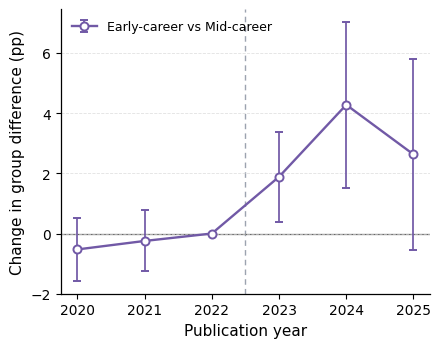

Displayed: Early-career vs Mid-career


In [26]:
early_career_plot_data = plot_event_study("early_career")
print("Displayed: Early-career vs Mid-career")

### Senior versus mid-career first authors

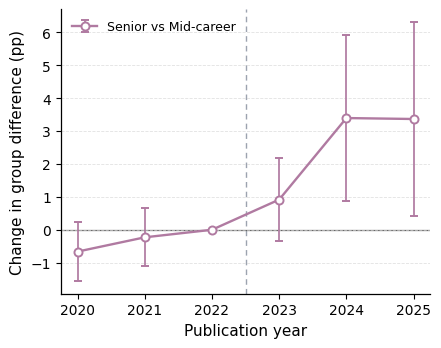

Displayed: Senior vs Mid-career


In [27]:
senior_plot_data = plot_event_study("senior")
print("Displayed: Senior vs Mid-career")

### Non-English versus English language environments

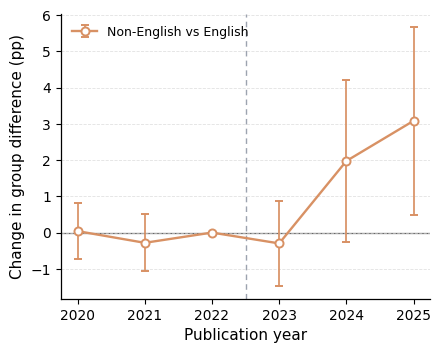

Displayed: Non-English vs English


In [28]:
language_plot_data = plot_event_study("language_environment")
print("Displayed: Non-English vs English")

### Non-main versus main conference tracks

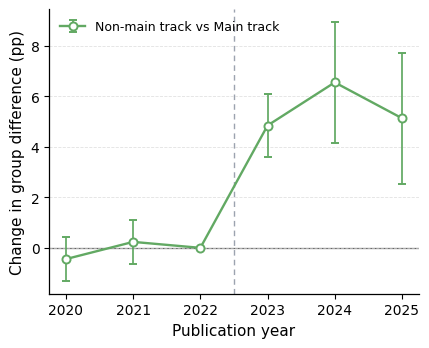

Displayed: Non-main track vs Main track


In [29]:
track_plot_data = plot_event_study("conference_track")
print("Displayed: Non-main track vs Main track")